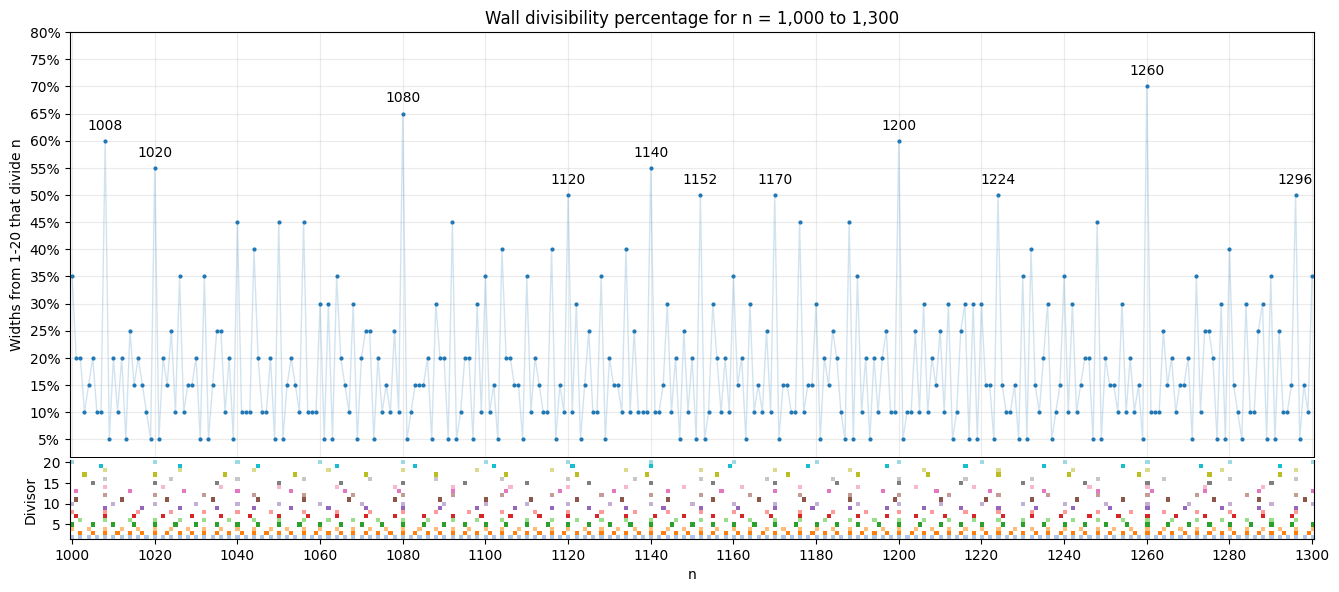

In [1]:
import matplotlib.pyplot as plt
import numpy as np

DIVISOR_RANGE = 20
MIN_N = 1_000
MAX_N = 1_300
CURRENT_N = 1_123
n_values = range(MIN_N, MAX_N + 1)
percentages = [
    100
    * (1 + sum(n % divisor == 0 for divisor in range(2, DIVISOR_RANGE + 1)))
    / DIVISOR_RANGE
    for n in n_values
]

fig, (ax, heatmap_ax) = plt.subplots(
    2,
    1,
    figsize=(13.5, 6),
    sharex=True,
    gridspec_kw={"height_ratios": (5, 1), "hspace": 0},
)
ax.plot(n_values, percentages, linewidth=1, alpha=0.2, color="C0")
ax.plot(
    n_values,
    percentages,
    linestyle="none",
    marker=".",
    markersize=4,
    color="C0",
)

# highlight current value
# current_percentage = percentages[CURRENT_N - MIN_N]
# ax.scatter(CURRENT_N, current_percentage, color="C1", s=6, zorder=3)

ax.set(
    title=f"Wall divisibility percentage for n = {MIN_N:,} to {MAX_N:,}",
    ylabel="Widths from 1-20 that divide n",
)
ax.set_yticks(range(5, 81, 5))
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0f}%")
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
for n, percentage in zip(n_values, percentages, strict=True):
    if percentage >= 50:
        ax.annotate(
            str(n),
            (n, percentage),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )
ax.grid(alpha=0.25)
ax.spines["bottom"].set_linewidth(0.72)

tab20 = plt.colormaps["tab20"].colors
heatmap = np.zeros((DIVISOR_RANGE - 1, len(n_values), 4))
for divisor in range(2, DIVISOR_RANGE + 1):
    divides = [n % divisor == 0 for n in n_values]
    heatmap[divisor - 2, divides] = (*tab20[divisor - 1], 1)
heatmap_ax.imshow(
    heatmap,
    origin="lower",
    interpolation="none",
    aspect="equal",
    extent=(MIN_N - 0.5, MAX_N + 0.5, 1.5, DIVISOR_RANGE + 0.5),
)
heatmap_ax.set(
    xlabel="n",
    ylabel="Divisor",
    ylim=(1.5, DIVISOR_RANGE + 0.5),
)
heatmap_ax.set_xticks(range(MIN_N, MAX_N + 1, 20))
heatmap_ax.set_yticks([5, 10, 15, 20])
heatmap_ax.spines["top"].set_visible(False)

fig.tight_layout()
plt.show()

In [2]:
def prime_factors(n: int) -> list[int]:
    if not isinstance(n, int) or n <= 1:
        raise ValueError("Requires an integer of 2 or more.")
    prime_factors = []

    for factor in (2, 3):
        while n % factor == 0:
            prime_factors.append(factor)
            n //= factor

    factor = 5
    stride = 2
    while factor * factor <= n:
        if n % factor == 0:
            prime_factors.append(factor)
            n //= factor
        else:
            factor += stride
            stride = 6 - stride # 2, 4, 2, ...

    if n > 1:
        prime_factors.append(n)

    return prime_factors

In [3]:
from math import prod

for n in range(2, 10_000):
    factors = prime_factors(n)
    assert prod(factors) == n, f"{n}: {factors}"
    for factor in factors:
        assert len(prime_factors(factor)) == 1

In [4]:

prime_factors(1260)

[2, 2, 3, 3, 5, 7]